In [1]:
knitr::opts_chunk$set(
  collapse = TRUE,
  comment = "#>",
  fig.width = 7,
  fig.height = 5,
  dpi = 96,
  out.width = "100%",
  message = FALSE,
  warning = FALSE
)

library(pagoda2)
library(ggplot2)


Loading required package: Matrix



Loading required package: igraph




Attaching package: ‘igraph’




The following objects are masked from ‘package:stats’:

    decompose, spectrum




The following object is masked from ‘package:base’:

    union





## Overview

This vignette shows the standard pagoda2.1 workflow for one single-cell RNA-seq
dataset. The input is a 10x-style count matrix with genes in rows and cells in
columns. The output is a processed `Pagoda2` object with QC metrics, PCA, a
nearest-neighbor graph, UMAP coordinates, Leiden clusters, marker genes, and
publication-ready summary plots.

Pagoda2.1 is designed so the common path is short:

```r
p2 <- Pagoda2$from10x(data_dir)
p2$run()
p2$plotEmbedding()
p2$plotMarkerDotPlot()
p2$plotMarkerHeatmap()
```

The sections below show the default workflow and the main inspection plots. QC
can be inspected before the full run, but the default `run()` call will perform
QC, filter cells, choose analysis genes, and then continue through PCA, graph
construction, UMAP, Leiden clustering, and markers.

## Data

The example uses the first sample from GSE192391, `GSM5746259`. Set
`PAGODA2_GSM5746259_10X` if the triplet files are stored somewhere else.



In [2]:
sample_dir <- Sys.getenv("PAGODA2_GSM5746259_10X", unset = "")
if (!dir.exists(sample_dir)) {
  candidates <- c(
    file.path("..", "..", "tests", "data", "GSE192391", "GSM5746259_MGI0369_1_SLAB-145-0"),
    file.path("..", "tests", "data", "GSE192391", "GSM5746259_MGI0369_1_SLAB-145-0"),
    file.path("tests", "data", "GSE192391", "GSM5746259_MGI0369_1_SLAB-145-0")
  )
  sample_dir <- candidates[dir.exists(candidates)][1]
}
stopifnot(dir.exists(sample_dir))



Create the pagoda2 object directly from the sample directory:



In [3]:
p2 <- Pagoda2$from10x(sample_dir)

counts <- p2$getRawCounts()
c(cells = nrow(counts), genes = ncol(counts))


Reading 10x matrix: ../../tests/data/GSE192391/GSM5746259_MGI0369_1_SLAB-145-0/GSM5746259_MGI0369_1_SLAB-145-0.matrix.mtx.gz



7532 cells, 36601 genes; normalizing ... 



Using plain model 



log scale ... 



done.




cells genes 
 7532 36601


`Pagoda2$from10x()` reads the count triplet, keeps raw counts in the object, and
sets up the default normalized expression view used by downstream methods.

## Optional QC Inspection

The QC step records molecule counts, detected-gene counts, and a default
gene-versus-molecule pass/fail decision in `p2$cellMeta`. If common
mitochondrial or ribosomal gene prefixes are present, it also records optional
composition metrics. This inspection step is optional: `p2$run()` will call it
if the metrics are missing.



In [4]:
p2$runQC(verbose = TRUE)


QC: 7532 cells; molecules median 3800 [IQR 2569-5582]; genes median 1536 [IQR 1155-2049]; 117 failed (1.55%)



QC composition: percent_mito: 13 genes (auto pattern `^MT-`); percent_ribo: 103 genes (auto pattern `^RP[SL]`)




Most workflow methods are quiet by default. Use `verbose = TRUE` when you want a
short progress or summary message.

The QC plot shows the relationship between molecule counts and detected genes.
Cells flagged by the default rule are shown in red.



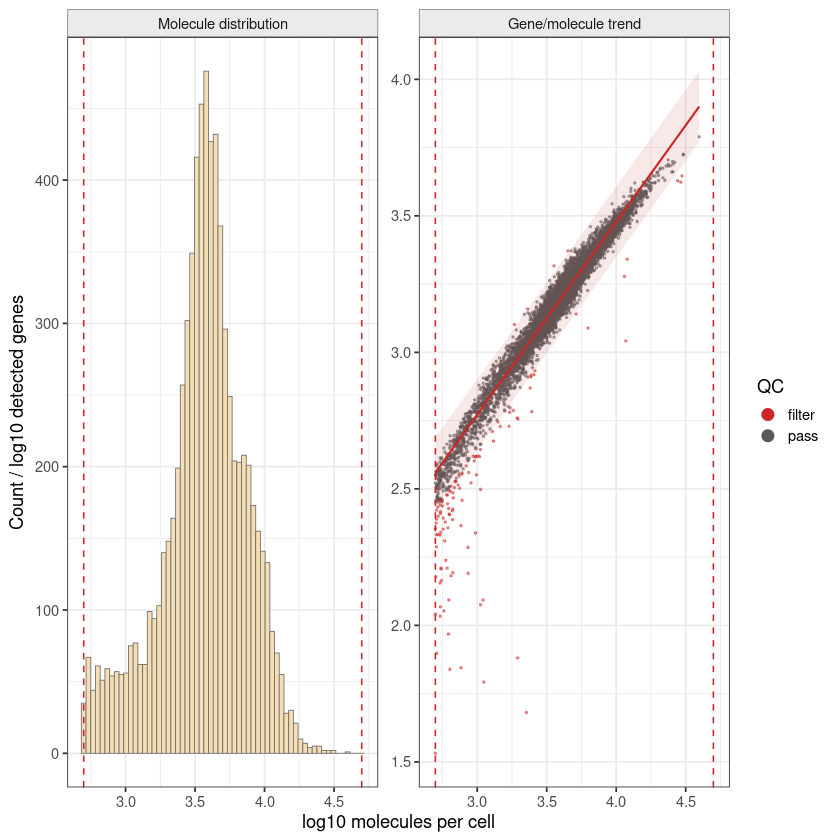

In [5]:
p2$plotQC()



Mitochondrial and ribosomal percentages are gene-annotation dependent. When
automatic prefix matching is not appropriate, pass explicit gene sets or regular
expressions to `runQC()`.



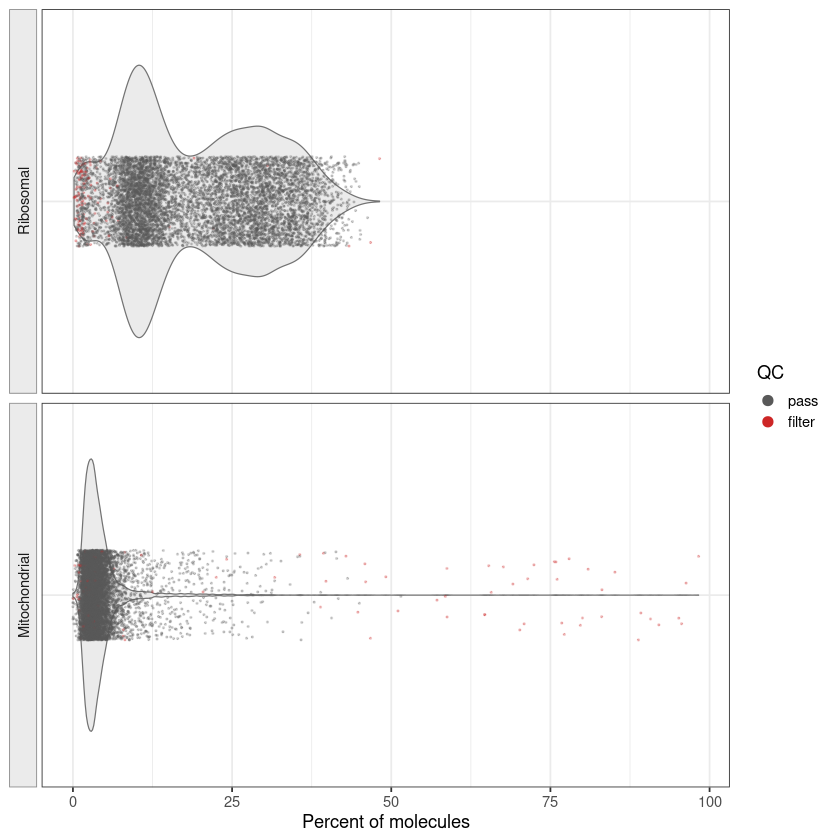

In [6]:
p2$plotQCViolin()



`filterData()` is the standard pre-analysis filter. It removes cells that fail
QC and records the analysis gene mask in `p2$geneMeta$analysis_pass`. It does
not drop raw genes from `p2$getRawCounts()`.

## Run The Default Workflow

The default run performs filtering, variance modeling, PCA, graph construction,
UMAP, Leiden clustering, and marker detection. Results are stored under
canonical names so later plotting calls can usually omit selectors.



In [7]:
p2$run(plots = "none")



After filtering, the current object keeps the filtered cell axis and the full
raw gene axis. Downstream analysis uses the analysis gene mask.



In [8]:
c(
  cells = nrow(p2$getRawCounts()),
  raw_genes = ncol(p2$getRawCounts()),
  analysis_genes = sum(p2$resolveGeneMeta("analysis_pass")$analysis_pass)
)


cells      raw_genes analysis_genes 
          7415          36601          17064


After the run, the default grouping is the Leiden clustering:



In [9]:
p2$getDefaultGrouping()
table(p2$getGrouping())


[1] "leiden"


   1    2    3    4    5    6    7    8    9   10   11   12   13 
1362  887  850  681  674  584  514  491  480  457  206  117  112 


## PCA Elbow Plot

The PCA elbow plot helps show how much of the total PCA-input variance is
captured by each component. The solid curve shows the percent explained by each
component; the blue curve shows the cumulative amount explained.



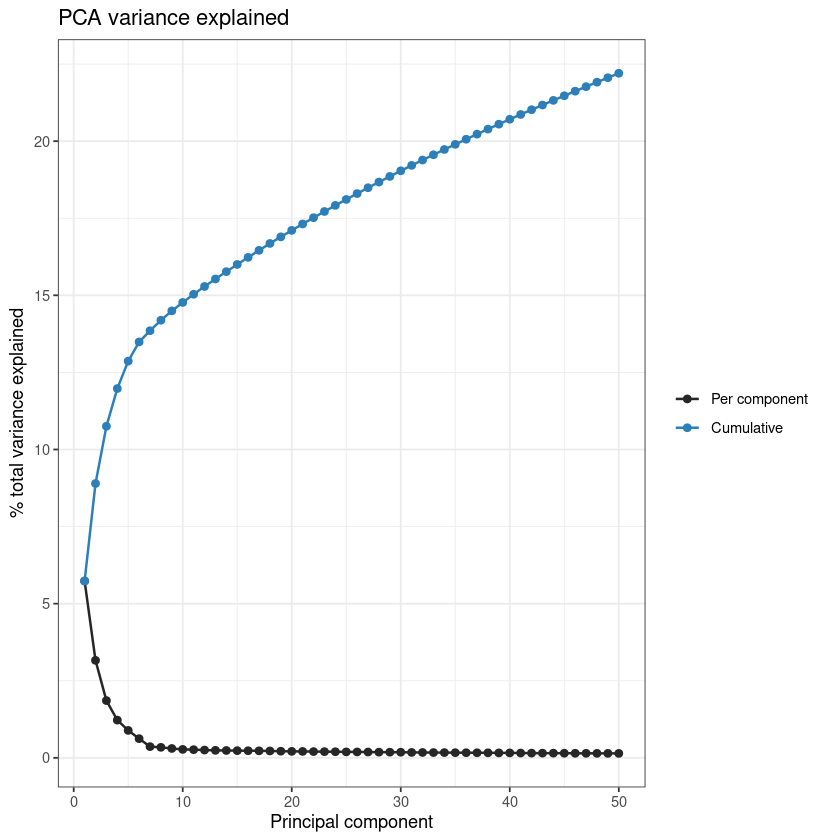

In [10]:
p2$plotPCAElbow()



## UMAP

`plotEmbedding()` uses the default PCA reduction, default UMAP embedding, and
default grouping unless you specify otherwise.



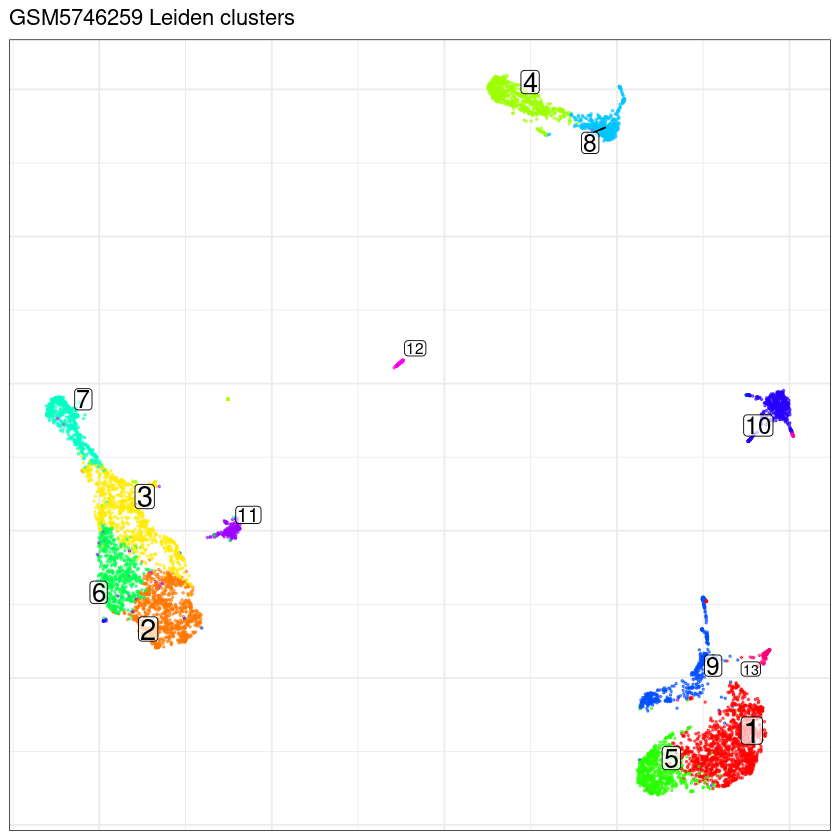

In [11]:
p2$plotEmbedding(
  mark.groups = TRUE,
  size = 0.35,
  alpha = 0.55,
  title = "GSM5746259 Leiden clusters"
)



## Marker Genes

The default run stores marker genes for the default grouping. A dot plot gives a
compact summary of marker expression by cluster.



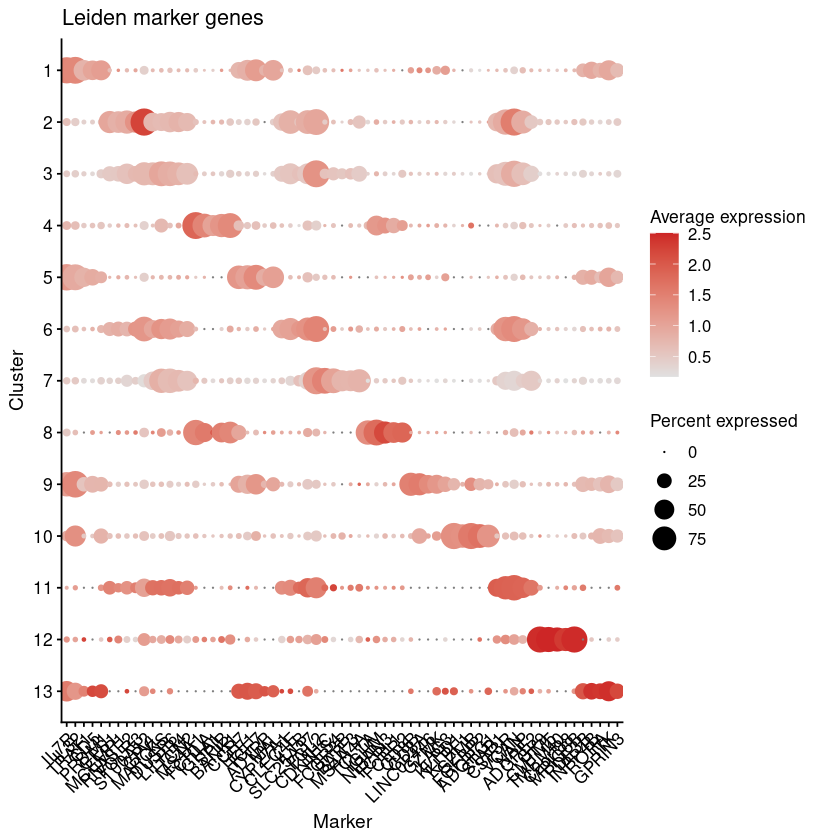

In [12]:
p2$plotMarkerDotPlot(n.genes.per.group = 5) +
  labs(title = "Leiden marker genes")



The native marker heatmap uses the same marker result and grouping. Here the
top annotation tracks show the QC metrics calculated earlier.



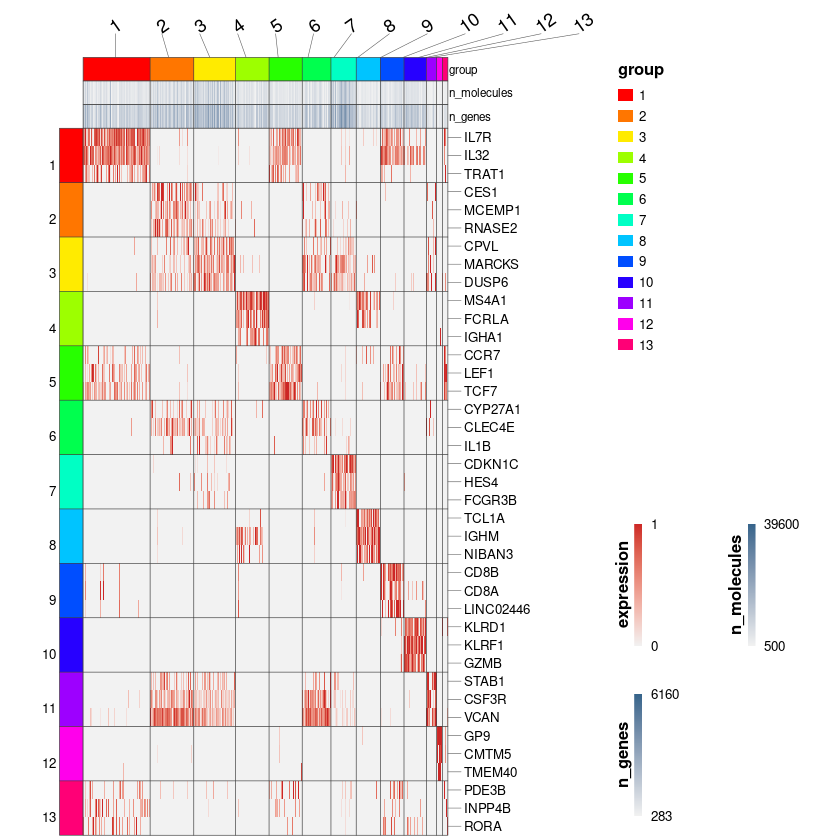

In [13]:
p2$plotMarkerHeatmap(
  engine = "native",
  n.genes.per.group = 3,
  column.metadata = c("n_molecules", "n_genes"),
  row.label.font.size = 8,
  split = TRUE,
  show_heatmap_legend = TRUE
)



## What To Do Next

For real analyses, the next step is usually biological annotation. You can store
cluster annotations as another cell metadata column and make it the default
grouping:

```r
p2$annotateClusters(
  from = "leiden",
  to = "cell_type",
  map = c("1" = "T cells", "2" = "monocytes"),
  setDefault = TRUE
)
```

After that, the same plotting and marker methods will use `cell_type` by default
unless you request a different grouping.
